In [1]:
import importlib
import sys
import numpy as np

# performance imports for torch: torch kernel uses one core only.
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["TORCH_NUM_THREADS"] = "1" 

import torch

sys.path.insert(0, '..')
sys.path.insert(0, '../..')
sys.path.insert(0, '../../..')
sys.path.insert(0, '../../../..')

In [2]:
import data.labeling_encoding
importlib.reload(data.labeling_encoding)
from data.labeling_encoding import PrefixesDataFrameLoader, EventLogLoader

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

np.random.seed(17)

event_log_location = '../../../../../../data/data/helpdesk.csv'

result_name = 'helpdesk_all'

# dynamic categorical attributes
cat_dynamic = ['Activity', 'Resource']

# static categorical attributes
#'VariantIndex',
cat_static =  ['VariantIndex',
               'seriousness',
               'customer',
               'product',
               'responsible_section',
               'seriousness_2',
               'service_level',
               'service_type',
               'support_section',
               'workgroup']

# dynamic numerical attributes
num_dynamic = ['case_elapsed_time',
               'event_elapsed_time',
               'day_in_week',
               'seconds_in_day']
num_dyn_log = []

# static numeric attributes
num_static = []

min_suffix_size = 5

# 20% test size:
test_validation_size = 0.2

event_log_properties = {# case id
                        'case_name' : 'CaseID',
                        # activity
                        'concept_name' : 'Activity',
                        # time values and computaitons
                        'timestamp_name' : 'CompleteTimestamp',
                        'date_format' : '%Y/%m/%d %H:%M:%S.%f',
                        'time_since_case_start_column' : 'case_elapsed_time',
                        'time_since_last_event_column' : 'event_elapsed_time',
                        'day_in_week_column' : 'day_in_week',
                        'seconds_in_day_column' : 'seconds_in_day',
                        # min suffix size for eos padding right
                        'min_suffix_size' : min_suffix_size,
                        # train and test split
                        'train_validation_size' : 0.15,
                        'test_validation_size' : test_validation_size,
                        # window size for padding
                        'window_size' : 'auto',
                        # dynamic and static values
                        'categorical_columns' : cat_dynamic,
                        'static_categorical_columns' : cat_static,
                        'continuous_columns' : num_dynamic,
                        'continuous_positive_columns' : num_dyn_log,
                        'static_continuous_columns' : num_static}


## Create dataframes of prefixes

In [3]:
# object to create datframe of prefixes for petri-net repaly marking computation
pref_adopt_dataframe = PrefixesDataFrameLoader(event_log_location=event_log_location, event_log_properties=event_log_properties)

In [4]:
# output if necessary the raw dataframe: dynamic are lists, static values
raw_data = pref_adopt_dataframe.get_raw_dataframe()
raw_data

,CaseID,Activity,Resource,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,VariantIndex,seriousness,customer,product,responsible_section,seriousness_2,service_level,service_type,support_section,workgroup
0,Case 1,"[Assign seriousness, Take in charge ticket, Ta...","[Value 1, Value 1, Value 2, Value 1, Value 3]","[0.0, 44.0, 259959.0, 1371849.0, 2671462.0]","[nan, 44.0, 259915.0, 1111890.0, 1299613.0]","[1, 1, 4, 3, 4]","[53417, 53461, 54176, 42866, 46479]",12,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1
1,Case 2,"[Assign seriousness, Take in charge ticket, Re...","[Value 4, Value 4, Value 4, Value 5]","[0.0, 15.0, 174014.0, 3974690.0]","[nan, 15.0, 173999.0, 3800676.0]","[1, 1, 3, 5]","[32138, 32153, 33352, 32428]",1,Value 1,Value 2,Value 2,Value 1,Value 1,Value 2,Value 1,Value 1,Value 1
2,Case 3,"[Assign seriousness, Take in charge ticket, Re...","[Value 6, Value 7, Value 7, Value 5]","[0.0, 453725.0, 454031.0, 2768772.0]","[nan, 453725.0, 306.0, 2314741.0]","[4, 2, 2, 1]","[36846, 58571, 58877, 40818]",1,Value 1,Value 3,Value 3,Value 1,Value 2,Value 2,Value 1,Value 1,Value 1
3,Case 4,"[Assign seriousness, Take in charge ticket, Re...","[Value 8, Value 2, Value 2, Value 5]","[0.0, 62954.0, 63386.0, 5098129.0]","[nan, 62954.0, 432.0, 5034743.0]","[2, 3, 3, 5]","[52313, 28867, 29299, 52842]",1,Value 1,Value 4,Value 3,Value 1,Value 2,Value 2,Value 1,Value 1,Value 1
4,Case 5,"[Assign seriousness, Take in charge ticket, Re...","[Value 9, Value 10, Value 10, Value 10, Value ...","[0.0, 2221.0, 2330.0, 3990.0, 10736.0, 4492916.0]","[nan, 2221.0, 109.0, 1660.0, 6746.0, 4482180.0]","[1, 1, 1, 1, 1, 4]","[47312, 49533, 49642, 51302, 58048, 47428]",9,Value 1,Value 5,Value 3,Value 1,Value 2,Value 3,Value 1,Value 1,Value 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4575,Case 4576,"[Assign seriousness, Take in charge ticket, Re...","[Value 2, Value 2, Value 2, Value 5]","[0.0, 19.0, 4260.0, 2678905.0]","[nan, 19.0, 4241.0, 2674645.0]","[1, 1, 1, 4]","[37311, 37330, 41571, 37816]",1,Value 1,Value 68,Value 1,Value 1,Value 1,Value 2,Value 1,Value 1,Value 1
4576,Case 4577,"[Assign seriousness, Take in charge ticket, Re...","[Value 2, Value 2, Value 2, Value 5]","[0.0, 1706476.0, 1706481.0, 4298498.0]","[nan, 1706476.0, 5.0, 2592017.0]","[2, 1, 1, 3]","[55731, 34207, 34212, 34229]",1,Value 1,Value 204,Value 3,Value 6,Value 1,Value 2,Value 1,Value 5,Value 1
4577,Case 4578,"[Assign seriousness, Resolve ticket, Closed]","[Value 1, Value 1, Value 5]","[0.0, 138.0, 2678945.0]","[nan, 138.0, 2678807.0]","[2, 2, 5]","[48070, 48208, 48615]",5,Value 1,Value 51,Value 8,Value 1,Value 1,Value 2,Value 1,Value 1,Value 1
4578,Case 4579,"[Assign seriousness, Take in charge ticket, Re...","[Value 9, Value 9, Value 9, Value 5]","[0.0, 12564.0, 12576.0, 3283705.0]","[nan, 12564.0, 12.0, 3271129.0]","[0, 0, 0, 3]","[36155, 48719, 48731, 36660]",1,Value 1,Value 71,Value 3,Value 1,Value 1,Value 3,Value 1,Value 1,Value 1


In [5]:
# outputs for perturbations:
# train_df, val_df, test_df = pref_adopt_dataframe.get_all_datasets()
# categories = pref_adopt_dataframe.extract_feature_info()

In [6]:
# prefix dataset for potential marking computation
train_pref_df = pref_adopt_dataframe.get_dataset('train')
train_pref_df

,CaseID,prefix_length,Activity,Resource,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,VariantIndex,seriousness,customer,product,responsible_section,seriousness_2,service_level,service_type,support_section,workgroup
0,Case 2,1,[Assign seriousness],[Value 4],[0.0],[nan],[1.0],[32138.0],1,Value 1,Value 2,Value 2,Value 1,Value 1,Value 2,Value 1,Value 1,Value 1
1,Case 2,2,"[Assign seriousness, Take in charge ticket]","[Value 4, Value 4]","[0.0, 15.0]","[nan, 15.0]","[1.0, 1.0]","[32138.0, 32153.0]",1,Value 1,Value 2,Value 2,Value 1,Value 1,Value 2,Value 1,Value 1,Value 1
2,Case 2,3,"[Assign seriousness, Take in charge ticket, Re...","[Value 4, Value 4, Value 4]","[0.0, 15.0, 174014.0]","[nan, 15.0, 173999.0]","[1.0, 1.0, 3.0]","[32138.0, 32153.0, 33352.0]",1,Value 1,Value 2,Value 2,Value 1,Value 1,Value 2,Value 1,Value 1,Value 1
3,Case 2,4,"[Assign seriousness, Take in charge ticket, Re...","[Value 4, Value 4, Value 4, Value 5]","[0.0, 15.0, 174014.0, 3974690.0]","[nan, 15.0, 173999.0, 3800676.0]","[1.0, 1.0, 3.0, 5.0]","[32138.0, 32153.0, 33352.0, 32428.0]",1,Value 1,Value 2,Value 2,Value 1,Value 1,Value 2,Value 1,Value 1,Value 1
4,Case 3,1,[Assign seriousness],[Value 6],[0.0],[nan],[4.0],[36846.0],1,Value 1,Value 3,Value 3,Value 1,Value 2,Value 2,Value 1,Value 1,Value 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13883,Case 4574,4,"[Assign seriousness, Take in charge ticket, Re...","[Value 8, Value 8, Value 8, Value 5]","[0.0, 22.0, 68724.0, 5094527.0]","[nan, 22.0, 68702.0, 5025803.0]","[3.0, 3.0, 4.0, 6.0]","[48104.0, 48126.0, 30428.0, 45031.0]",1,Value 1,Value 227,Value 2,Value 1,Value 2,Value 2,Value 1,Value 1,Value 1
13884,Case 4577,1,[Assign seriousness],[Value 2],[0.0],[nan],[2.0],[55731.0],1,Value 1,Value 204,Value 3,Value 6,Value 1,Value 2,Value 1,Value 5,Value 1
13885,Case 4577,2,"[Assign seriousness, Take in charge ticket]","[Value 2, Value 2]","[0.0, 1706476.0]","[nan, 1706476.0]","[2.0, 1.0]","[55731.0, 34207.0]",1,Value 1,Value 204,Value 3,Value 6,Value 1,Value 2,Value 1,Value 5,Value 1
13886,Case 4577,3,"[Assign seriousness, Take in charge ticket, Re...","[Value 2, Value 2, Value 2]","[0.0, 1706476.0, 1706481.0]","[nan, 1706476.0, 5.0]","[2.0, 1.0, 1.0]","[55731.0, 34207.0, 34212.0]",1,Value 1,Value 204,Value 3,Value 6,Value 1,Value 2,Value 1,Value 5,Value 1


In [7]:
train_pref_df.to_csv('../../../../data/Helpdesk/raw_data/'+result_name+'_'+str(min_suffix_size)+'_train.csv', index=False)

In [8]:
# prefix dataset for potential marking computation
val_pref_df = pref_adopt_dataframe.get_dataset('val')
val_pref_df

,CaseID,prefix_length,Activity,Resource,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,VariantIndex,seriousness,customer,product,responsible_section,seriousness_2,service_level,service_type,support_section,workgroup
0,Case 1,1,[Assign seriousness],[Value 1],[0.0],[nan],[1.0],[53417.0],12,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1
1,Case 1,2,"[Assign seriousness, Take in charge ticket]","[Value 1, Value 1]","[0.0, 44.0]","[nan, 44.0]","[1.0, 1.0]","[53417.0, 53461.0]",12,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1
2,Case 1,3,"[Assign seriousness, Take in charge ticket, Ta...","[Value 1, Value 1, Value 2]","[0.0, 44.0, 259959.0]","[nan, 44.0, 259915.0]","[1.0, 1.0, 4.0]","[53417.0, 53461.0, 54176.0]",12,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1
3,Case 1,4,"[Assign seriousness, Take in charge ticket, Ta...","[Value 1, Value 1, Value 2, Value 1]","[0.0, 44.0, 259959.0, 1371849.0]","[nan, 44.0, 259915.0, 1111890.0]","[1.0, 1.0, 4.0, 3.0]","[53417.0, 53461.0, 54176.0, 42866.0]",12,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1
4,Case 1,5,"[Assign seriousness, Take in charge ticket, Ta...","[Value 1, Value 1, Value 2, Value 1, Value 3]","[0.0, 44.0, 259959.0, 1371849.0, 2671462.0]","[nan, 44.0, 259915.0, 1111890.0, 1299613.0]","[1.0, 1.0, 4.0, 3.0, 4.0]","[53417.0, 53461.0, 54176.0, 42866.0, 46479.0]",12,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3196,Case 4561,8,"[Assign seriousness, Take in charge ticket, Wa...","[Value 14, Value 14, Value 14, Value 5, Value ...","[0.0, 15.0, 64.0, 846558.0, 846567.0, 1526580....","[nan, 15.0, 49.0, 846494.0, 9.0, 680013.0, 14....","[4.0, 4.0, 4.0, 0.0, 0.0, 1.0, 1.0, 2.0]","[56944.0, 56959.0, 57008.0, 39502.0, 39511.0, ...",22,Value 1,Value 66,Value 3,Value 1,Value 2,Value 2,Value 1,Value 1,Value 1
3197,Case 4580,1,[Take in charge ticket],[Value 6],[0.0],[nan],[1.0],[34423.0],18,Value 1,Value 92,Value 3,Value 1,Value 2,Value 2,Value 2,Value 1,Value 1
3198,Case 4580,2,"[Take in charge ticket, Wait]","[Value 6, Value 6]","[0.0, 626188.0]","[nan, 626188.0]","[1.0, 1.0]","[34423.0, 55811.0]",18,Value 1,Value 92,Value 3,Value 1,Value 2,Value 2,Value 2,Value 1,Value 1
3199,Case 4580,3,"[Take in charge ticket, Wait, Resolve ticket]","[Value 6, Value 6, Value 6]","[0.0, 626188.0, 632037.0]","[nan, 626188.0, 5849.0]","[1.0, 1.0, 1.0]","[34423.0, 55811.0, 61660.0]",18,Value 1,Value 92,Value 3,Value 1,Value 2,Value 2,Value 2,Value 1,Value 1


In [9]:
val_pref_df.to_csv('../../../../data/Helpdesk/raw_data/'+result_name+'_'+str(min_suffix_size)+'_val.csv', index=False)

In [10]:
# prefix dataset for potential marking computation
test_pref_df = pref_adopt_dataframe.get_dataset('test')
test_pref_df

,CaseID,prefix_length,Activity,Resource,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,VariantIndex,seriousness,customer,product,responsible_section,seriousness_2,service_level,service_type,support_section,workgroup
0,Case 21,1,[Assign seriousness],[Value 8],[0.0],[nan],[4.0],[54921.0],1,Value 1,Value 13,Value 1,Value 1,Value 2,Value 3,Value 1,Value 1,Value 1
1,Case 21,2,"[Assign seriousness, Take in charge ticket]","[Value 8, Value 2]","[0.0, 1097476.0]","[nan, 1097476.0]","[4.0, 3.0]","[54921.0, 29197.0]",1,Value 1,Value 13,Value 1,Value 1,Value 2,Value 3,Value 1,Value 1,Value 1
2,Case 21,3,"[Assign seriousness, Take in charge ticket, Re...","[Value 8, Value 2, Value 2]","[0.0, 1097476.0, 1105434.0]","[nan, 1097476.0, 7958.0]","[4.0, 3.0, 3.0]","[54921.0, 29197.0, 37155.0]",1,Value 1,Value 13,Value 1,Value 1,Value 2,Value 3,Value 1,Value 1,Value 1
3,Case 21,4,"[Assign seriousness, Take in charge ticket, Re...","[Value 8, Value 2, Value 2, Value 5]","[0.0, 1097476.0, 1105434.0, 3697456.0]","[nan, 1097476.0, 7958.0, 2592022.0]","[4.0, 3.0, 3.0, 5.0]","[54921.0, 29197.0, 37155.0, 37177.0]",1,Value 1,Value 13,Value 1,Value 1,Value 2,Value 3,Value 1,Value 1,Value 1
4,Case 25,1,[Assign seriousness],[Value 13],[0.0],[nan],[3.0],[34037.0],1,Value 1,Value 22,Value 3,Value 1,Value 1,Value 2,Value 1,Value 1,Value 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4254,Case 4578,3,"[Assign seriousness, Resolve ticket, Closed]","[Value 1, Value 1, Value 5]","[0.0, 138.0, 2678945.0]","[nan, 138.0, 2678807.0]","[2.0, 2.0, 5.0]","[48070.0, 48208.0, 48615.0]",5,Value 1,Value 51,Value 8,Value 1,Value 1,Value 2,Value 1,Value 1,Value 1
4255,Case 4579,1,[Assign seriousness],[Value 9],[0.0],[nan],[0.0],[36155.0],1,Value 1,Value 71,Value 3,Value 1,Value 1,Value 3,Value 1,Value 1,Value 1
4256,Case 4579,2,"[Assign seriousness, Take in charge ticket]","[Value 9, Value 9]","[0.0, 12564.0]","[nan, 12564.0]","[0.0, 0.0]","[36155.0, 48719.0]",1,Value 1,Value 71,Value 3,Value 1,Value 1,Value 3,Value 1,Value 1,Value 1
4257,Case 4579,3,"[Assign seriousness, Take in charge ticket, Re...","[Value 9, Value 9, Value 9]","[0.0, 12564.0, 12576.0]","[nan, 12564.0, 12.0]","[0.0, 0.0, 0.0]","[36155.0, 48719.0, 48731.0]",1,Value 1,Value 71,Value 3,Value 1,Value 1,Value 3,Value 1,Value 1,Value 1


In [11]:
test_pref_df.to_csv('../../../../data/Helpdesk/raw_data/'+result_name+'_'+str(min_suffix_size)+'_test.csv', index=False)

## Optional: Compute Petri Net replay markings of prefixes 

In [12]:
# Optional set list of ids the petri net should be executed:
unique_list_train = train_pref_df["CaseID"].dropna().unique().tolist()
unique_list_val = val_pref_df["CaseID"].dropna().unique().tolist()

case_ids = list(dict.fromkeys(unique_list_train + unique_list_val))

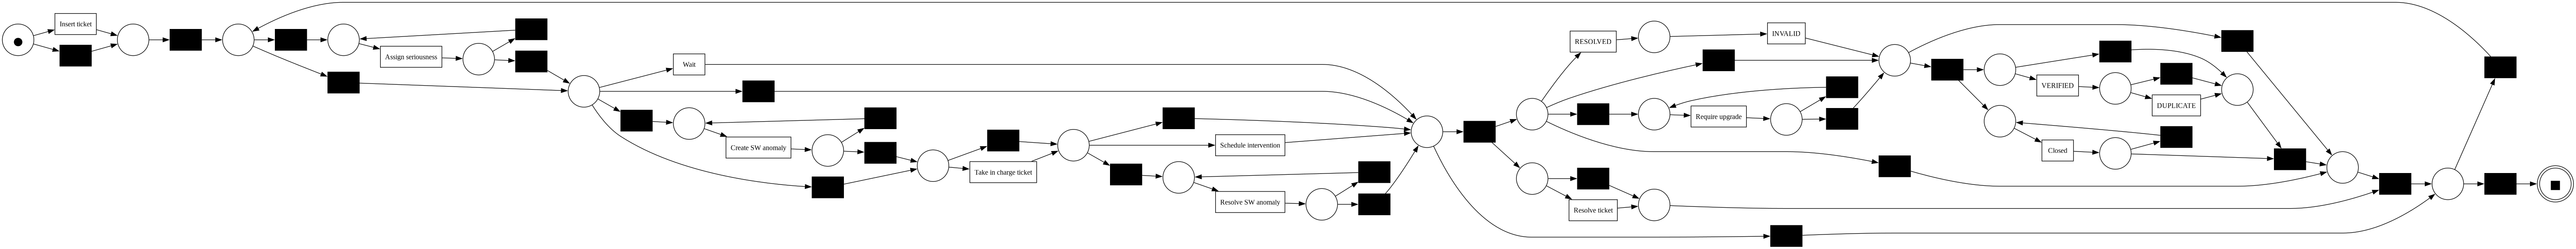

In [13]:
# Calculate and store markings:
import os
import pickle
import data.petri_net_replay_markings
importlib.reload(data.petri_net_replay_markings)
from data.petri_net_replay_markings import InductiveMiner

# initialize the process 
miner = InductiveMiner(path_to_csv_log=event_log_location, case_id_col="CaseID", activity_col="Activity", timestamp_col="CompleteTimestamp", resource_col="Resource")
store_loc_file_path = '../../../../data/Helpdesk/Petri_net/helpdesk.png'
net, im, fm = miner.discover_petri_net(visulaize=True,
                                       case_ids=case_ids,
                                       store_loc_file_path=store_loc_file_path)

# store discovered petri net objects next to the PNG
pkl_path = os.path.splitext(store_loc_file_path)[0] + '.pkl'
with open(pkl_path, 'wb') as f:
    pickle.dump((net, im, fm), f)

## Store "normal" tensor-datasets

In [14]:
# object to create the tensors for the dnn models and further credentials
el_loader = EventLogLoader(event_log_location=event_log_location, event_log_properties=event_log_properties, prefix_df=pref_adopt_dataframe)

In [15]:
# train tensor dataset
train_set = el_loader.get_dataset('train')

# save dataset 
torch.save(train_set, '../../../../data/Helpdesk/tensor_data/normal/'+result_name+'_'+str(el_loader.encoder_decoder.min_suffix_size)+'_train.pkl')

categorical tensors:   0%|          | 0/2 [00:00<?, ?it/s]

Activity:   0%|          | 0/2977 [00:00<?, ?it/s]

Resource:   0%|          | 0/2977 [00:00<?, ?it/s]

continouous tensors:   0%|          | 0/4 [00:00<?, ?it/s]

case_elapsed_time:   0%|          | 0/2977 [00:00<?, ?it/s]

event_elapsed_time:   0%|          | 0/2977 [00:00<?, ?it/s]

day_in_week:   0%|          | 0/2977 [00:00<?, ?it/s]

seconds_in_day:   0%|          | 0/2977 [00:00<?, ?it/s]

static categorical:   0%|          | 0/13888 [00:00<?, ?it/s]

In [16]:
# Test get sizes and others
print("Min suffix size: ", train_set.min_suffix_size)

print("Categories and encoding params for dynamic categorical and continuous values: ", train_set.all_categories)
print("Categories and encoding params for static categorical and continuous values: ", train_set.all_static_categories)

print("Dynamic categorical tensor: ", train_set.categorical_tensors[0].size())
print("Dynamic continuous tensor: ", train_set.continuous_tensors[0].size())

print("Static categorical tensor: ", train_set.static_categorical_tensor.size())
print("Static continuous tensor: ", train_set.static_continuous_tensor.size())

print("Zero padding tensor: ", train_set.zero_padding.size())
print("EOS padding tensor: ",train_set.eos_padding.size())

if isinstance(train_set.decision_data, torch.Tensor):
    print("Decision data tensor: ", train_set.decision_data.size())
else:
    print("Decision data: ", len(train_set.decision_data))
    print("Decision data: ", len(train_set.decision_data[0]) if len(train_set.decision_data) > 0 else 0)

# print(train_set.prefixes_petri_net_marking[0:3])

Min suffix size:  5
Categories and encoding params for dynamic categorical and continuous values:  ([('Activity', 15, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'EOS': 4, 'INVALID': 5, 'Insert ticket': 6, 'RESOLVED': 7, 'Require upgrade': 8, 'Resolve SW anomaly': 9, 'Resolve ticket': 10, 'Schedule intervention': 11, 'Take in charge ticket': 12, 'VERIFIED': 13, 'Wait': 14}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('seconds_in_day', 1, {})])
Categories and encoding params for static categorical and continuous values:  ([('VariantIndex', 175, {'1': 1, '10': 2, '10

In [17]:
# train tensor dataset
val_set = el_loader.get_dataset('val')

# save dataset 
torch.save(val_set, '../../../../data/Helpdesk/tensor_data/normal/'+result_name+'_'+str(el_loader.encoder_decoder.min_suffix_size)+'_val.pkl')

categorical tensors:   0%|          | 0/2 [00:00<?, ?it/s]

Activity:   0%|          | 0/687 [00:00<?, ?it/s]

Resource:   0%|          | 0/687 [00:00<?, ?it/s]

continouous tensors:   0%|          | 0/4 [00:00<?, ?it/s]

case_elapsed_time:   0%|          | 0/687 [00:00<?, ?it/s]

event_elapsed_time:   0%|          | 0/687 [00:00<?, ?it/s]

day_in_week:   0%|          | 0/687 [00:00<?, ?it/s]

seconds_in_day:   0%|          | 0/687 [00:00<?, ?it/s]

static categorical:   0%|          | 0/3201 [00:00<?, ?it/s]

In [18]:
# Test get sizes and others
print("Min suffix size: ", val_set.min_suffix_size)

print("Categories and encoding params for dynamic categorical and continuous values: ", val_set.all_categories)
print("Categories and encoding params for static categorical and continuous values: ", val_set.all_static_categories)

print("Dynamic categorical tensor: ", val_set.categorical_tensors[0].size())
print("Dynamic continuous tensor: ", val_set.continuous_tensors[0].size())

print("Static categorical tensor: ", val_set.static_categorical_tensor.size())
print("Static continuous tensor: ", val_set.static_continuous_tensor.size())

print("Zero padding tensor: ", val_set.zero_padding.size())
print("EOS padding tensor: ",val_set.eos_padding.size())

# print("Prefix petri net replay tensor: ", len(val_set.prefixes_petri_net_marking))
# print(val_set.prefixes_petri_net_marking[0:3])

Min suffix size:  5
Categories and encoding params for dynamic categorical and continuous values:  ([('Activity', 15, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'EOS': 4, 'INVALID': 5, 'Insert ticket': 6, 'RESOLVED': 7, 'Require upgrade': 8, 'Resolve SW anomaly': 9, 'Resolve ticket': 10, 'Schedule intervention': 11, 'Take in charge ticket': 12, 'VERIFIED': 13, 'Wait': 14}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('seconds_in_day', 1, {})])
Categories and encoding params for static categorical and continuous values:  ([('VariantIndex', 175, {'1': 1, '10': 2, '10

In [19]:
# train tensor dataset
test_set = el_loader.get_dataset('test')

# save dataset 
torch.save(test_set, '../../../../data/Helpdesk/tensor_data/normal/'+result_name+'_'+str(el_loader.encoder_decoder.min_suffix_size)+'_test.pkl')

categorical tensors:   0%|          | 0/2 [00:00<?, ?it/s]

Activity:   0%|          | 0/916 [00:00<?, ?it/s]

Resource:   0%|          | 0/916 [00:00<?, ?it/s]

continouous tensors:   0%|          | 0/4 [00:00<?, ?it/s]

case_elapsed_time:   0%|          | 0/916 [00:00<?, ?it/s]

event_elapsed_time:   0%|          | 0/916 [00:00<?, ?it/s]

day_in_week:   0%|          | 0/916 [00:00<?, ?it/s]

seconds_in_day:   0%|          | 0/916 [00:00<?, ?it/s]

static categorical:   0%|          | 0/4259 [00:00<?, ?it/s]

In [20]:
# Test get sizes and others
print("Min suffix size: ", test_set.min_suffix_size)

print("Categories and encoding params for dynamic categorical and continuous values: ", test_set.all_categories)
print("Categories and encoding params for static categorical and continuous values: ", test_set.all_static_categories)

print("Dynamic categorical tensor: ", test_set.categorical_tensors[0].size())
# print("Dynamic categorical tensor examples: ", test_set.categorical_tensors[0][10:55])
print("Dynamic continuous tensor: ", test_set.continuous_tensors[0].size())

print("Static categorical tensor: ", test_set.static_categorical_tensor.size())
print("Static continuous tensor: ", test_set.static_continuous_tensor.size())

print("Zero padding tensor: ", test_set.zero_padding.size())
print("EOS padding tensor: ",test_set.eos_padding.size())
# print("Zero padds: ", test_set.zero_padding[35:41])
# print("EOS padds: ", test_set.eos_padding[35:41])

# print("Prefix petri net replay tensor: ", len(test_set.prefixes_petri_net_marking))
# print(test_set.prefixes_petri_net_marking[0:3])

Min suffix size:  5
Categories and encoding params for dynamic categorical and continuous values:  ([('Activity', 15, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'EOS': 4, 'INVALID': 5, 'Insert ticket': 6, 'RESOLVED': 7, 'Require upgrade': 8, 'Resolve SW anomaly': 9, 'Resolve ticket': 10, 'Schedule intervention': 11, 'Take in charge ticket': 12, 'VERIFIED': 13, 'Wait': 14}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('seconds_in_day', 1, {})])
Categories and encoding params for static categorical and continuous values:  ([('VariantIndex', 175, {'1': 1, '10': 2, '10

## Store "decision-labeled" tensor-datasets 